In [2]:
import fastf1
import pandas as pd

# The cache prevents data from being re-downloaded every time you run the code
fastf1.Cache.enable_cache('../data/cache')

print("FastF1 version:", fastf1.__version__)
print("Pandas version:", pd.__version__)

FastF1 version: 3.8.1
Pandas version: 2.3.3


In [6]:
# We upload the qualifying session for the 2024 Spanish GP
# Parameters: year, GP name, session type
session = fastf1.get_session(2024, 'Spain', 'Q')

# load() downloads all the data: laps, telemetry, weather...
# The first time takes ~1-2 minutes. Subsequent times take less than 5 seconds thanks to the cache.
session.load()

print("Session loaded:", session.event['EventName'], session.name)

core           INFO 	Loading data for Spanish Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '44', '63', '16', '55', '10', '11', '31', '81', '14', '77', '27', '18', '24', '20', '22', '3', '23', '2']


Session loaded: Spanish Grand Prix Qualifying


In [7]:
# session.laps is a DataFrame containing all the laps of all the drivers
laps = session.laps

# .shape tells us how many rows and columns it has
print("DataFrame Dimensions:", laps.shape)

# .columns lists all available columns
print("\nAvailable columns:")
print(list(laps.columns))

DataFrame Dimensions: (257, 31)

Available columns:
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


In [8]:
# `.head(10)` displays the first 10 rows — essential for understanding the data
laps.head(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:20:31.873000,NOR,4,NaT,1.0,1.0,0 days 00:18:42.073000,NaT,NaT,0 days 00:00:37.675000,...,True,McLaren,0 days 00:18:42.073000,2024-06-22 14:05:14.990,1,NaN,False,,False,False
1,0 days 00:21:44.259000,NOR,4,0 days 00:01:12.386000,2.0,1.0,NaT,NaT,0 days 00:00:21.579000,0 days 00:00:28.941000,...,True,McLaren,0 days 00:20:31.873000,2024-06-22 14:07:04.790,1,NaN,False,,False,True
2,0 days 00:23:24.351000,NOR,4,0 days 00:01:40.092000,3.0,1.0,NaT,0 days 00:23:21.511000,0 days 00:00:29.738000,0 days 00:00:38.386000,...,True,McLaren,0 days 00:21:44.259000,2024-06-22 14:08:17.176,1,NaN,False,,False,False
3,0 days 00:45:41.347000,NOR,4,NaT,4.0,2.0,0 days 00:43:45.157000,NaT,NaT,0 days 00:00:38.634000,...,True,McLaren,0 days 00:23:24.351000,2024-06-22 14:09:57.268,1,NaN,False,,False,False
4,0 days 00:46:53.219000,NOR,4,0 days 00:01:11.872000,5.0,2.0,NaT,NaT,0 days 00:00:21.455000,0 days 00:00:28.691000,...,True,McLaren,0 days 00:45:41.347000,2024-06-22 14:32:14.264,1,NaN,False,,False,True
5,0 days 00:49:03.883000,NOR,4,0 days 00:02:10.664000,6.0,2.0,NaT,0 days 00:48:28.969000,0 days 00:00:27.774000,0 days 00:00:37.208000,...,True,McLaren,0 days 00:46:53.219000,2024-06-22 14:33:26.136,1,NaN,False,,False,False
6,0 days 01:05:11.205000,NOR,4,NaT,7.0,3.0,0 days 01:03:08.470000,NaT,NaT,0 days 00:00:39.494000,...,True,McLaren,0 days 00:49:03.883000,2024-06-22 14:35:36.800,1,NaN,False,,False,False
7,0 days 01:06:23.001000,NOR,4,0 days 00:01:11.796000,8.0,3.0,NaT,NaT,0 days 00:00:21.463000,0 days 00:00:28.592000,...,True,McLaren,0 days 01:05:11.205000,2024-06-22 14:51:44.122,1,NaN,False,,False,True
8,0 days 01:07:59.561000,NOR,4,0 days 00:01:36.560000,9.0,3.0,NaT,0 days 01:07:56.796000,0 days 00:00:27.389000,0 days 00:00:36.987000,...,True,McLaren,0 days 01:06:23.001000,2024-06-22 14:52:55.918,1,NaN,False,,False,False
9,0 days 01:13:07.570000,NOR,4,NaT,10.0,4.0,0 days 01:10:56.124000,NaT,NaT,0 days 00:00:39.279000,...,True,McLaren,0 days 01:07:59.561000,2024-06-22 14:54:32.478,12,NaN,False,,False,False


In [9]:
# We only filtered out Verstappen's laps
# In F1, each driver has a 3-letter code
verstappen = laps.pick_drivers('VER')

print(f"Verstappen's laps: {len(verstappen)}")

# We display the most relevant columns
verstappen[['LapNumber', 'LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Compound', 'TyreLife']].head(15)

Verstappen's laps: 12


,LapNumber,LapTime,Sector1Time,Sector2Time,Sector3Time,Compound,TyreLife
12,1.0,NaT,NaT,0 days 00:00:40.931000,0 days 00:00:25.920000,SOFT,1.0
13,2.0,0 days 00:01:12.306000,0 days 00:00:21.680000,0 days 00:00:28.887000,0 days 00:00:21.739000,SOFT,2.0
14,3.0,0 days 00:01:42.809000,0 days 00:00:29.797000,0 days 00:00:42.484000,0 days 00:00:30.528000,SOFT,3.0
15,4.0,NaT,NaT,0 days 00:00:37.176000,0 days 00:00:24.866000,SOFT,1.0
16,5.0,0 days 00:01:11.653000,0 days 00:00:21.520000,0 days 00:00:28.553000,0 days 00:00:21.580000,SOFT,2.0
17,6.0,0 days 00:01:35.627000,0 days 00:00:27.350000,0 days 00:00:36.626000,0 days 00:00:31.651000,SOFT,3.0
18,7.0,NaT,NaT,0 days 00:00:40.293000,0 days 00:00:25.394000,SOFT,1.0
19,8.0,0 days 00:01:11.673000,0 days 00:00:21.527000,0 days 00:00:28.595000,0 days 00:00:21.551000,SOFT,2.0
20,9.0,0 days 00:01:38.172000,0 days 00:00:28.860000,0 days 00:00:38.176000,0 days 00:00:31.136000,SOFT,3.0
21,10.0,NaT,NaT,0 days 00:00:40.264000,0 days 00:00:25.316000,SOFT,1.0


In [10]:
# pick_fastest() automatically filters for the fastest lap
fastest__verstappen_lap = verstappen.pick_fastest()

print("Fastest lap time:", fastest__verstappen_lap['LapTime'])
print("Sector 1:", fastest__verstappen_lap['Sector1Time'])
print("Sector 2:", fastest__verstappen_lap['Sector2Time'])
print("Sector 3:", fastest__verstappen_lap['Sector3Time'])
print("Compound:", fastest__verstappen_lap['Compound'])

Fastest lap time: 0 days 00:01:11.403000
Sector 1: 0 days 00:00:21.369000
Sector 2: 0 days 00:00:28.541000
Sector 3: 0 days 00:00:21.493000
Compound: SOFT


In [12]:
# .get_telemetry() returns another DataFrame with the data at 10Hz
# 'distance' adds a column with the distance traveled in meters
ver_telemetry = fastest__verstappen_lap.get_telemetry().add_distance()

print("Telemetry points:", len(ver_telemetry))
print("\nTelemetry columns:")
print(list(ver_telemetry.columns))

ver_telemetry.head(10)

Telemetry points: 550

Telemetry columns:
['Date', 'SessionTime', 'DriverAhead', 'DistanceToDriverAhead', 'Time', 'RPM', 'Speed', 'nGear', 'Throttle', 'Brake', 'DRS', 'Source', 'RelativeDistance', 'Status', 'X', 'Y', 'Z', 'Distance']


,Date,SessionTime,DriverAhead,DistanceToDriverAhead,Time,RPM,Speed,nGear,Throttle,Brake,DRS,Source,RelativeDistance,Status,X,Y,Z,Distance
2,2024-06-22 14:59:13.643,0 days 01:12:40.726000,,176.585833,0 days 00:00:00,10752.000038,300.300001,8,100.0,False,12,interpolation,0.000001,OnTrack,1342.798196,-304.068657,1706.930529,0.000000
3,2024-06-22 14:59:13.760,0 days 01:12:40.843000,,176.585833,0 days 00:00:00.117000,10787.100019,301.470001,8,100.0,False,12,pos,0.002108,OnTrack,1266.000000,-424.000000,1707.000000,9.797775
4,2024-06-22 14:59:13.813,0 days 01:12:40.896000,,176.585833,0 days 00:00:00.170000,10803.000000,302.000000,8,100.0,False,12,car,0.003066,OnTrack,1233.773353,-474.534674,1707.095949,14.243886
5,2024-06-22 14:59:14.052,0 days 01:12:41.135000,11,176.585833,0 days 00:00:00.409000,10884.000000,305.000000,8,100.0,False,12,car,0.007415,OnTrack,1110.412858,-669.271398,1707.856657,34.492497
6,2024-06-22 14:59:14.120,0 days 01:12:41.203000,11,176.378056,0 days 00:00:00.477000,10902.912500,305.637500,8,100.0,False,12,pos,0.008659,OnTrack,1084.000000,-711.000000,1708.000000,40.265650
7,2024-06-22 14:59:14.372,0 days 01:12:41.455000,11,175.608056,0 days 00:00:00.729000,10973.000000,308.000000,8,100.0,False,12,car,0.013294,OnTrack,1017.700971,-815.358573,1708.045655,61.825650
8,2024-06-22 14:59:14.480,0 days 01:12:41.563000,11,175.038056,0 days 00:00:00.837000,11024.300000,309.080000,8,100.0,False,12,pos,0.015290,OnTrack,983.000000,-870.000000,1708.000000,71.098050
9,2024-06-22 14:59:14.572,0 days 01:12:41.655000,11,174.552500,0 days 00:00:00.929000,11068.000000,310.000000,8,100.0,False,12,car,0.016993,OnTrack,944.179336,-931.218416,1707.979579,79.020272
10,2024-06-22 14:59:14.720,0 days 01:12:41.803000,11,173.483611,0 days 00:00:01.077000,11068.000000,310.740000,8,100.0,False,12,pos,0.019738,OnTrack,872.000000,-1045.000000,1708.000000,91.795139
11,2024-06-22 14:59:14.772,0 days 01:12:41.855000,11,173.108056,0 days 00:00:01.129000,11068.000000,311.000000,8,100.0,False,12,car,0.020704,OnTrack,847.134422,-1084.113400,1708.030001,96.287361


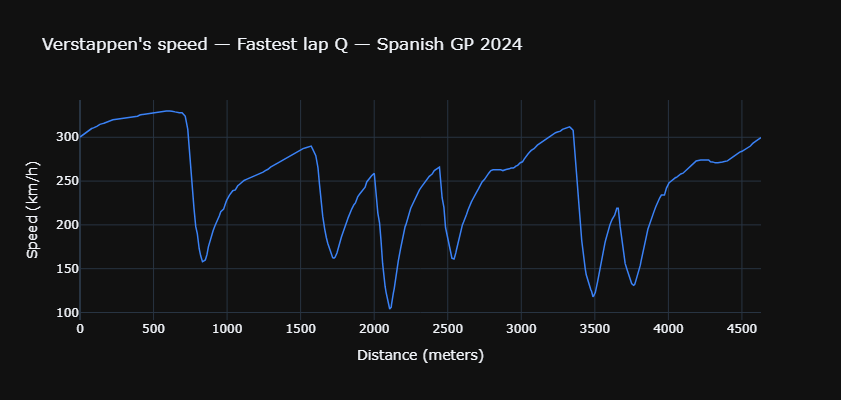

In [17]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ver_telemetry['Distance'],
    y=ver_telemetry['Speed'],
    mode='lines',
    name='Verstappen',
    line=dict(color='#3B82F6', width=1.5)
))

fig.update_layout(
    title="Verstappen's speed — Fastest lap Q — Spanish GP 2024",
    xaxis_title='Distance (meters)',
    yaxis_title='Speed (km/h)',
    template='plotly_dark',
    height=400
)

fig.show()